# Задание 3. Кластеризация банковских транзакций

Нужно подготовить данные, применить PCA и выполнить кластеризацию k-means.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler

## 1. Загружаем данные

In [2]:
LOCAL_DATA_PATHS = [
    Path("data/bank_transactions.csv"),
    Path("../data/bank_transactions.csv"),
    Path("clusterisation/data/bank_transactions.csv"),
    Path("bank_transactions.csv"),
]

for path in LOCAL_DATA_PATHS:
    if path.exists():
        BANK_TRANSACTIONS_PATH = path
        break
else:
    raise FileNotFoundError("Не найден bank_transactions.csv. Проверь папку data/.")

print("Файл данных:", BANK_TRANSACTIONS_PATH)

bank_transactions = pd.read_csv(BANK_TRANSACTIONS_PATH, index_col="TransactionID")
bank_transactions.head()

Файл данных: ../data/bank_transactions.csv


,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
TransactionID,,,,,,,,
T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


## 2. Первичный анализ

In [3]:
print("Размер:", bank_transactions.shape)
display(bank_transactions.info())
display(bank_transactions.isna().sum())
display(bank_transactions.nunique())

Размер: (1048567, 8)
<class 'pandas.DataFrame'>
Index: 1048567 entries, T1 to T1048567
Data columns (total 8 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   CustomerID               1048567 non-null  str    
 1   CustomerDOB              1045170 non-null  str    
 2   CustGender               1047467 non-null  str    
 3   CustLocation             1048416 non-null  str    
 4   CustAccountBalance       1046198 non-null  float64
 5   TransactionDate          1048567 non-null  str    
 6   TransactionTime          1048567 non-null  int64  
 7   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), str(5)
memory usage: 72.0+ MB


None

CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance         2369
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64

CustomerID                 884265
CustomerDOB                 17254
CustGender                      3
CustLocation                 9355
CustAccountBalance         161328
TransactionDate                55
TransactionTime             81918
TransactionAmount (INR)     93024
dtype: int64

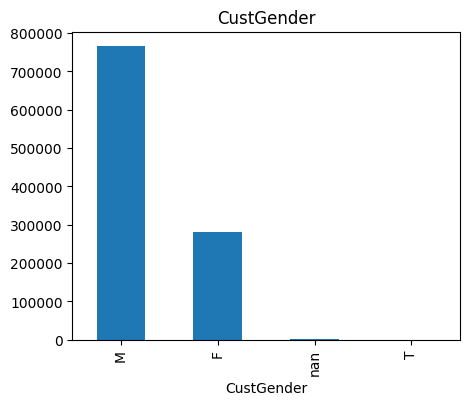

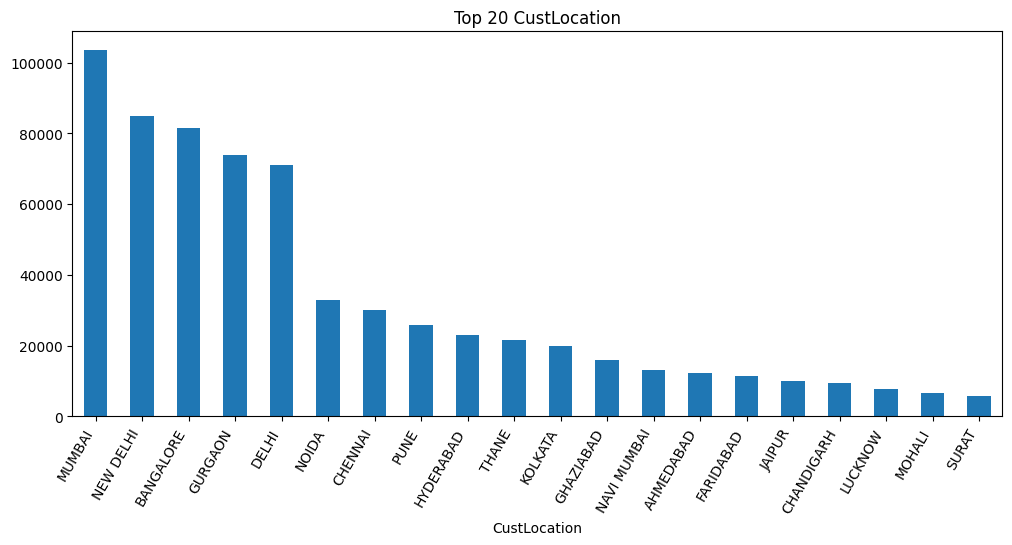

In [4]:
plt.figure(figsize=(5, 4))
bank_transactions["CustGender"].value_counts(dropna=False).plot(kind="bar")
plt.title("CustGender")
plt.show()

plt.figure(figsize=(12, 5))
bank_transactions["CustLocation"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 CustLocation")
plt.xticks(rotation=60, ha="right")
plt.show()

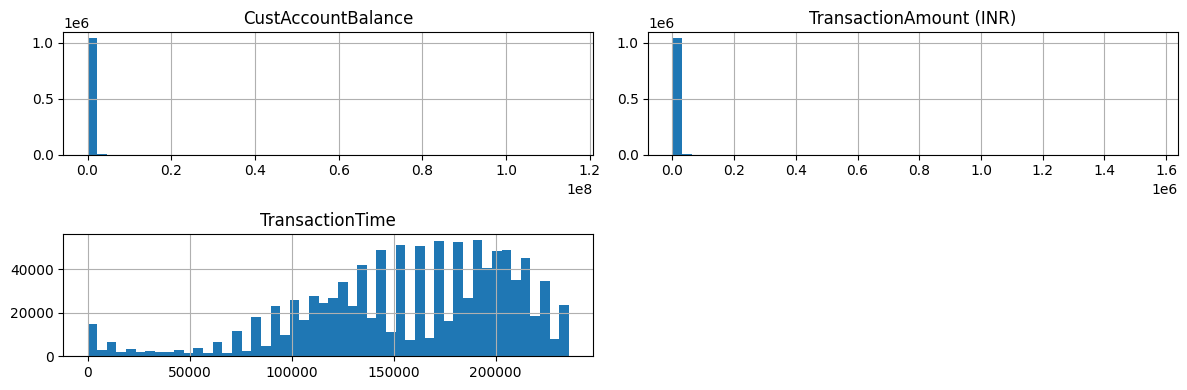

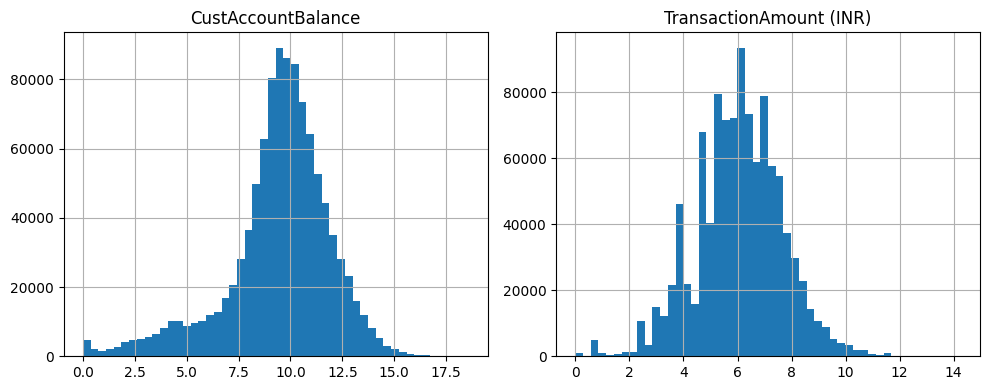

In [5]:
cols = ["CustAccountBalance", "TransactionAmount (INR)", "TransactionTime"]

bank_transactions[cols].hist(figsize=(12, 4), bins=50)
plt.tight_layout()
plt.show()

np.log1p(bank_transactions[["CustAccountBalance", "TransactionAmount (INR)"]]).hist(figsize=(10, 4), bins=50)
plt.tight_layout()
plt.show()

## 3. Подготовка признаков

Пропуски в балансе заполняем медианой. Для баланса и суммы транзакции используем `log1p`, потому что распределения сильно скошены вправо. Из времени берем час, из даты рождения считаем возраст. Редкие города объединяем в `OTHER`.

In [6]:
bank_transactions["CustAccountBalance"] = bank_transactions["CustAccountBalance"].fillna(
    bank_transactions["CustAccountBalance"].median()
)

bank_transactions["CustGender"] = bank_transactions["CustGender"].fillna("U")
bank_transactions["CustGender"] = bank_transactions["CustGender"].where(
    bank_transactions["CustGender"].isin(["M", "F"]), "U"
)

top_locations = bank_transactions["CustLocation"].value_counts().head(10).index
bank_transactions["CustLocation"] = bank_transactions["CustLocation"].fillna("OTHER")
bank_transactions["CustLocation"] = bank_transactions["CustLocation"].where(
    bank_transactions["CustLocation"].isin(top_locations), "OTHER"
)

bank_transactions["balance_log"] = np.log1p(bank_transactions["CustAccountBalance"])
bank_transactions["amount_log"] = np.log1p(bank_transactions["TransactionAmount (INR)"])
bank_transactions["transaction_hour"] = (bank_transactions["TransactionTime"] // 10000).clip(0, 23)

bank_transactions["CustomerDOB_dt"] = pd.to_datetime(
    bank_transactions["CustomerDOB"],
    format="%d/%m/%y",
    errors="coerce"
)

bank_transactions["TransactionDate_dt"] = pd.to_datetime(
    bank_transactions["TransactionDate"],
    format="%d/%m/%y",
    errors="coerce"
)

mask = bank_transactions["CustomerDOB_dt"] > bank_transactions["TransactionDate_dt"]
bank_transactions.loc[mask, "CustomerDOB_dt"] = (
    bank_transactions.loc[mask, "CustomerDOB_dt"] - pd.DateOffset(years=100)
)

bank_transactions["age"] = (
    bank_transactions["TransactionDate_dt"] - bank_transactions["CustomerDOB_dt"]
).dt.days / 365.25

bank_transactions["age"] = bank_transactions["age"].where(
    bank_transactions["age"].between(10, 100),
    np.nan
)

bank_transactions["age"] = bank_transactions["age"].fillna(bank_transactions["age"].median())

bank_transactions[["CustGender", "CustLocation", "balance_log", "amount_log", "transaction_hour", "age"]].head()

,CustGender,CustLocation,balance_log,amount_log,transaction_hour,age
TransactionID,,,,,,
T1,F,OTHER,9.788080,3.258097,14,22.559890
T2,M,OTHER,7.728279,10.239960,14,59.329227
T3,F,MUMBAI,9.791183,6.131226,14,19.682409
T4,F,MUMBAI,13.672222,7.630947,14,42.882957
T5,F,OTHER,8.812163,7.475056,18,28.358658


In [7]:
features = [
    "balance_log",
    "amount_log",
    "transaction_hour",
    "age",
    "CustGender",
    "CustLocation",
]

bank_features = bank_transactions[features]
bank_features = pd.get_dummies(bank_features, columns=["CustGender", "CustLocation"], dtype=int)

print(bank_features.shape)
bank_features.head()

(1048567, 18)


,balance_log,amount_log,transaction_hour,age,CustGender_F,CustGender_M,CustGender_U,CustLocation_BANGALORE,CustLocation_CHENNAI,CustLocation_DELHI,CustLocation_GURGAON,CustLocation_HYDERABAD,CustLocation_MUMBAI,CustLocation_NEW DELHI,CustLocation_NOIDA,CustLocation_OTHER,CustLocation_PUNE,CustLocation_THANE
TransactionID,,,,,,,,,,,,,,,,,,
T1,9.788080,3.258097,14,22.559890,1,0,0,0,0,0,0,0,0,0,0,1,0,0
T2,7.728279,10.239960,14,59.329227,0,1,0,0,0,0,0,0,0,0,0,1,0,0
T3,9.791183,6.131226,14,19.682409,1,0,0,0,0,0,0,0,1,0,0,0,0,0
T4,13.672222,7.630947,14,42.882957,1,0,0,0,0,0,0,0,1,0,0,0,0,0
T5,8.812163,7.475056,18,28.358658,1,0,0,0,0,0,0,0,0,0,0,1,0,0


## 4. Масштабирование

In [8]:
scaler = StandardScaler()
bank_scaled = scaler.fit_transform(bank_features)

bank_scaled[:5]

array([[ 0.13826648, -1.74173579, -0.27519301, -0.99760668,  1.64898962,
        -1.64459703, -0.0324208 , -0.29040853, -0.17164568, -0.2695369 ,
        -0.27519132, -0.14991821, -0.33110057, -0.29687133, -0.17965136,
         1.0465331 , -0.15898683, -0.14470095],
       [-0.68638945,  2.61091547, -0.27519301,  3.31782462, -0.60643196,
         0.60805169, -0.0324208 , -0.29040853, -0.17164568, -0.2695369 ,
        -0.27519132, -0.14991821, -0.33110057, -0.29687133, -0.17965136,
         1.0465331 , -0.15898683, -0.14470095],
       [ 0.13950898,  0.04943832, -0.27519301, -1.33532212,  1.64898962,
        -1.64459703, -0.0324208 , -0.29040853, -0.17164568, -0.2695369 ,
        -0.27519132, -0.14991821,  3.02023039, -0.29687133, -0.17965136,
        -0.95553595, -0.15898683, -0.14470095],
       [ 1.69331117,  0.9843977 , -0.27519301,  1.387609  ,  1.64898962,
        -1.64459703, -0.0324208 , -0.29040853, -0.17164568, -0.2695369 ,
        -0.27519132, -0.14991821,  3.02023039, -0.296

## 5. PCA вручную

In [9]:
def pca_manual(X, n_components=2):
    X_centered = X - X.mean(axis=0)
    cov_matrix = np.cov(X_centered, rowvar=False)

    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    components = eigenvectors[:, :n_components]
    X_pca = X_centered @ components
    explained_ratio = eigenvalues / eigenvalues.sum()

    return X_pca, components, explained_ratio

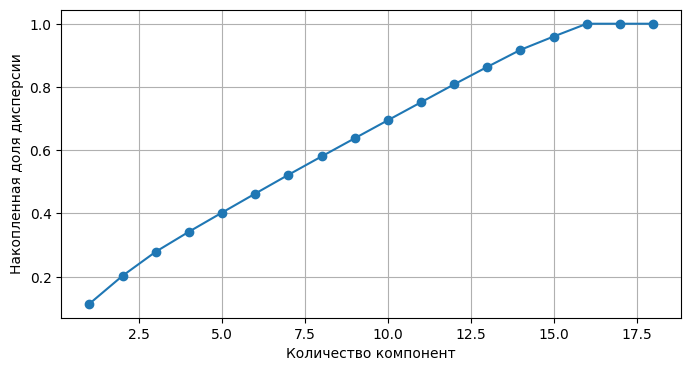

[0.11465682 0.08846484 0.07597908 0.06320224 0.06054062 0.06000723
 0.05937041 0.0580749  0.05742257 0.05705395]


In [10]:
bank_pca_2, bank_components_2, bank_explained_ratio = pca_manual(bank_scaled, n_components=2)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(bank_explained_ratio) + 1), np.cumsum(bank_explained_ratio), marker="o")
plt.xlabel("Количество компонент")
plt.ylabel("Накопленная доля дисперсии")
plt.grid()
plt.show()

print(bank_explained_ratio[:10])

In [11]:
N_COMPONENTS = 15
bank_pca, bank_components, bank_explained_ratio = pca_manual(bank_scaled, n_components=N_COMPONENTS)

print(bank_pca.shape)
print("Сохраненная дисперсия:", bank_explained_ratio[:N_COMPONENTS].sum())

(1048567, 15)
Сохраненная дисперсия: 0.9595699719439481


## 6. K-means вручную

In [12]:
def kmeans_manual(X, k, max_iter=100, random_state=42):
    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(X), k, replace=False)
    centroids = X[idx]

    for _ in range(max_iter):
        distances = np.sqrt(((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2))
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([
            X[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
            for i in range(k)
        ])

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels, centroids


def inertia_manual(X, labels, centroids):
    return sum(((X[labels == i] - centroids[i]) ** 2).sum() for i in range(len(centroids)))

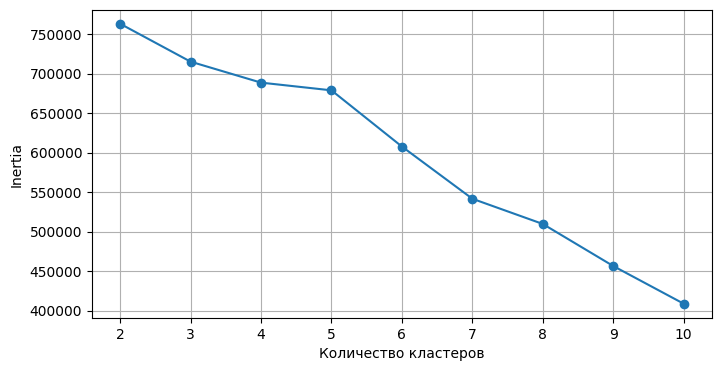

In [13]:
sample_size = min(50_000, len(bank_pca))
sample_idx = np.random.default_rng(42).choice(len(bank_pca), size=sample_size, replace=False)
bank_sample = bank_pca[sample_idx]

inertias = []

for k in range(2, 11):
    labels_sample, centroids_sample = kmeans_manual(bank_sample, k)
    inertias.append(inertia_manual(bank_sample, labels_sample, centroids_sample))

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), inertias, marker="o")
plt.xlabel("Количество кластеров")
plt.ylabel("Inertia")
plt.grid()
plt.show()

In [19]:
K = 7
bank_labels, bank_centroids = kmeans_manual(bank_pca, k=K)

bank_transactions["cluster"] = bank_labels
bank_transactions["cluster"].value_counts().sort_index()

cluster
0     30009
1     21505
2    219976
3    381398
4    240306
5     73818
6     81555
Name: count, dtype: int64

## 7. Интерпретация кластеров

In [20]:
bank_cluster_means = bank_transactions.groupby("cluster")[[
    "CustAccountBalance",
    "TransactionAmount (INR)",
    "balance_log",
    "amount_log",
    "transaction_hour",
    "age",
]].mean()

bank_cluster_means

,CustAccountBalance,TransactionAmount (INR),balance_log,amount_log,transaction_hour,age
cluster,,,,,,
0,91001.653319,1487.481137,9.369773,6.147474,15.730481,32.473720
1,66674.039417,1262.873780,9.213997,6.072596,15.599814,31.579628
2,103418.967254,1704.074053,9.663883,6.219426,15.648271,30.589808
3,94499.191450,1538.436595,9.150010,5.891704,15.244026,30.801121
4,151378.493011,1609.898370,9.566761,6.104101,15.302930,31.591970
5,177058.190010,1518.527926,9.973896,6.129387,15.480398,31.377684
6,102646.124326,1452.085624,9.455958,6.084952,15.639225,31.025762


In [21]:
pd.crosstab(bank_transactions["cluster"], bank_transactions["CustGender"], normalize="index")

CustGender,F,M,U
cluster,,,
0,0.240628,0.759339,0.000033
1,0.260730,0.738107,0.001163
2,1.000000,0.000000,0.000000
3,0.000000,0.999887,0.000113
4,0.000000,0.995797,0.004203
5,0.339741,0.660259,0.000000
6,0.294930,0.704800,0.000270


In [22]:
pd.crosstab(bank_transactions["cluster"], bank_transactions["CustLocation"], normalize="index")

CustLocation,BANGALORE,CHENNAI,DELHI,GURGAON,HYDERABAD,MUMBAI,NEW DELHI,NOIDA,OTHER,PUNE,THANE
cluster,,,,,,,,,,,
0,0.0,1.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
2,0.0,0.0,0.099647,0.0,0.028421,0.148353,0.111012,0.042273,0.540241,0.030053,0.0
3,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0
4,0.0,0.0,0.204319,0.0,0.069898,0.295294,0.251796,0.097730,0.000899,0.080065,0.0
5,0.0,0.0,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
6,1.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0


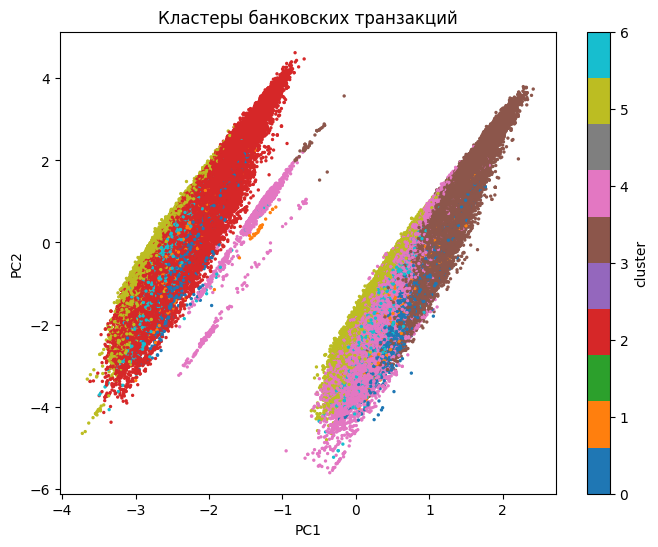

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(bank_pca_2[:, 0], bank_pca_2[:, 1], c=bank_labels, cmap="tab10", s=2)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Кластеры банковских транзакций")
plt.colorbar(label="cluster")
plt.show()

## Вывод

Кластеризация разделяет транзакции по сочетанию финансовых признаков, пола клиента, города, возраста и времени операции. Так как категориальные признаки были закодированы one-hot, часть кластеров может быть сильно связана с конкретными городами или группами городов. Для интерпретации используются средние значения по кластерам и доли категориальных признаков внутри каждого кластера.